# EDA FracAtlas — Clasificación fracturas

### Instalación de dependencias del proyecto

In [35]:
import os
import zipfile
from pathlib import Path
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from scipy import ndimage as ndi
from skimage import exposure
from tqdm import tqdm

# Semilla para reproducibilidad
random.seed(50)
np.random.seed(50)

# Configuración del proyecto
PROJECT_ROOT = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
RAW_PATH = PROJECT_ROOT / "data" / "raw"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

RAW_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [36]:
!curl -L -o "{RAW_PATH / 'fractatlas.zip'}" \
  "https://www.kaggle.com/api/v1/datasets/download/mahmudulhasantasin/fracatlas-original-dataset"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  0  322M    0  351k    0     0   284k      0  0:19:20  0:00:01  0:19:19  284k
  3  322M    3  9.8M    0     0  4529k      0  0:01:12  0:00:02  0:01:10 9773k
  6  322M    6 20.2M    0     0  6347k      0  0:00:52  0:00:03  0:00:49  9.8M
 10  322M   10 32.4M    0     0  7843k      0  0:00:42  0:00:04  0:00:38 10.6M
 13  322M   13 42.7M    0     0  8334k      0  0:00:39  0:00:05  0:00:34 10.5M
 16  322M   16 53.4M    0     0  8781k      0  0:00:37  0:00:06  0:00:31 10.6M
 19  322M   19 62.8M    0     0  8889k      0  0:00:37  0:00:07  0:00:30 10.5M
 22  322M   22 74.0M    0     0  9204k      0  0:0

In [37]:
# Definir las rutas para el archivo ZIP y la carpeta de extracción
zip_path = RAW_PATH / "fractatlas.zip"
extract_path = RAW_PATH / "FracAtlas"

if extract_path.exists() and any(extract_path.iterdir()):
    print("El dataset ya existe")
else:
    if not zip_path.exists():
        raise FileNotFoundError(f"El archivo ZIP no se encontró en: {zip_path}")

    extract_path.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    os.remove(zip_path)
    print("Dataset extraído correctamente")

# Ruta principal del dataset
DATASET_PATH = extract_path

# En algunos casos el ZIP puede traer una carpeta adicional adentro.
# Se mantiene simple: solo se corrige si la carpeta images no está directamente en extract_path.
if not (DATASET_PATH / "images").exists():
    posibles = list(DATASET_PATH.rglob("images"))
    if len(posibles) == 0:
        raise FileNotFoundError("No se encontró la carpeta images del dataset.")
    DATASET_PATH = posibles[0].parent

DATASET_PATH

El dataset ya existe


WindowsPath('c:/Users/USER/Downloads/TF IMAGENES/bone-fracture-classification/data/raw/FracAtlas/FracAtlas')

# Funciones utiles

In [38]:
# Función para calcular histograma en escala de grises
def calcular_histograma_gray(ruta):
    img = Image.open(ruta).convert("L")
    img_array = np.array(img)

    hist, _ = np.histogram(
        img_array.ravel(),
        bins=256,
        range=(0, 256),
        density=True
    )

    return hist

In [39]:
def visualizar_histogramas_por_categoria(df):
    categorias = sorted(df["categoria"].unique())

    n_categorias = len(categorias)
    columnas = 2
    filas = math.ceil(n_categorias / columnas)

    fig, axes = plt.subplots(filas, columnas, figsize=(16, filas * 4))

    if n_categorias == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    niveles_intensidad = np.arange(256)

    for i, categoria in enumerate(categorias):
        rutas_categoria = df[df["categoria"] == categoria]["ruta"]

        histogramas_categoria = []

        for ruta_relativa in rutas_categoria:
            ruta_absoluta = PROJECT_ROOT / ruta_relativa
            hist = calcular_histograma_gray(ruta_absoluta)
            histogramas_categoria.append(hist)

        hist_promedio = np.array(histogramas_categoria).mean(axis=0)

        axes[i].bar(niveles_intensidad, hist_promedio, width=3.0)
        axes[i].set_title(categoria)
        axes[i].set_xlabel("Nivel de intensidad")
        axes[i].set_ylabel("Frecuencia promedio")
        axes[i].set_xlim(-0.5, 255.5)
        axes[i].set_ylim(0, hist_promedio.max() * 1.1)
        axes[i].grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Histogramas promedio por categoría", fontsize=18)
    plt.tight_layout()
    plt.show()

### Visualizacion de la estructura de las carpetas del dataset

Inspeccion de la distribucion y estructura del dataset.

In [40]:
def mostrar_estructura(ruta: Path, nivel_max=4):
    for root, dirs, files in os.walk(ruta):
        nivel = root.replace(str(ruta), "").count(os.sep)

        if nivel > nivel_max:
            continue

        indentacion = "    " * nivel
        nombre_carpeta = os.path.basename(root)

        imagenes = [
            f for f in files
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
        ]

        print(f"{indentacion}{nombre_carpeta}/  ({len(imagenes)} imágenes)")

mostrar_estructura(DATASET_PATH, nivel_max=4)

FracAtlas/  (0 imágenes)
    Annotations/  (0 imágenes)
        COCO JSON/  (0 imágenes)
        PASCAL VOC/  (0 imágenes)
        VGG JSON/  (0 imágenes)
        YOLO/  (0 imágenes)
    images/  (0 imágenes)
        Fractured/  (717 imágenes)
        Non_fractured/  (3366 imágenes)
    Utilities/  (0 imágenes)
        Fracture Split/  (0 imágenes)


### Crear DataFrame con información de cada imagen

In [41]:
extensiones_img = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

rutas_imagenes = []

carpetas_clase = {
    "Fractured": "fractura",
    "Non_fractured": "no_fractura"
}

for carpeta_original in carpetas_clase.keys():
    carpeta = DATASET_PATH / "images" / carpeta_original
    if not carpeta.exists():
        raise FileNotFoundError(f"No se encontró la carpeta: {carpeta}")

    for root, dirs, files in os.walk(carpeta):
        for file in files:
            if file.lower().endswith(extensiones_img):
                rutas_imagenes.append(Path(root) / file)

print("Total de imágenes encontradas:", len(rutas_imagenes))

Total de imágenes encontradas: 4083


In [42]:
datos = []

for ruta in rutas_imagenes:
    categoria = carpetas_clase[ruta.parent.name]

    try:
        img = Image.open(ruta)

        ancho, alto = img.size
        modo = img.mode

        img_array = np.array(img)

        # Convertimos a escala de grises solo para estadísticas
        img_gray = img.convert("L")
        gray_array = np.array(img_gray)

        # Verificar si visualmente es gris aunque esté guardada como RGB
        if img_array.ndim == 3 and img_array.shape[2] >= 3:
            es_gris_visual = np.allclose(img_array[:, :, 0], img_array[:, :, 1]) and                              np.allclose(img_array[:, :, 1], img_array[:, :, 2])
        else:
            es_gris_visual = True

        ruta_relativa = ruta.relative_to(PROJECT_ROOT)

        datos.append({
            "ruta": str(ruta_relativa),
            "archivo": ruta.name,
            "categoria": categoria,
            "ancho": ancho,
            "alto": alto,
            "pixeles_totales": ancho * alto,
            "relacion_aspecto": ancho / alto,
            "modo": modo,
            "es_gris_visual": es_gris_visual,
            "intensidad_min": gray_array.min(),
            "intensidad_max": gray_array.max(),
            "intensidad_media": gray_array.mean(),
            "intensidad_std": gray_array.std()
        })

    except Exception as e:
        print("Error leyendo:", ruta)
        print(e)

df = pd.DataFrame(datos)

# FracAtlas no viene dividido en Train/Test por carpetas, así que generamos un split simple y estratificado.
df["split"] = "Train"
for categoria in df["categoria"].unique():
    idx_categoria = df[df["categoria"] == categoria].index.tolist()
    n_test = int(len(idx_categoria) * 0.2)
    idx_test = random.sample(idx_categoria, n_test)
    df.loc[idx_test, "split"] = "Test"

df.head()

,ruta,archivo,categoria,ancho,alto,pixeles_totales,relacion_aspecto,modo,es_gris_visual,intensidad_min,intensidad_max,intensidad_media,intensidad_std,split
0,data\raw\FracAtlas\FracAtlas\images\Fractured\...,IMG0000019.jpg,fractura,2304,2880,6635520,0.80,L,True,0,255,58.519365,54.458437,Train
1,data\raw\FracAtlas\FracAtlas\images\Fractured\...,IMG0000025.jpg,fractura,2880,2304,6635520,1.25,L,True,0,254,28.336379,57.458927,Train
2,data\raw\FracAtlas\FracAtlas\images\Fractured\...,IMG0000044.jpg,fractura,2304,2880,6635520,0.80,L,True,0,255,70.376494,63.267692,Train
3,data\raw\FracAtlas\FracAtlas\images\Fractured\...,IMG0000057.jpg,fractura,2304,2880,6635520,0.80,L,True,0,255,67.780325,88.693883,Train
4,data\raw\FracAtlas\FracAtlas\images\Fractured\...,IMG0000058.jpg,fractura,2304,2880,6635520,0.80,L,True,0,255,91.471452,73.674882,Train


In [43]:
df.shape

(4083, 14)

### Visualización de histograma de intensidad media para identificar posibles outliers

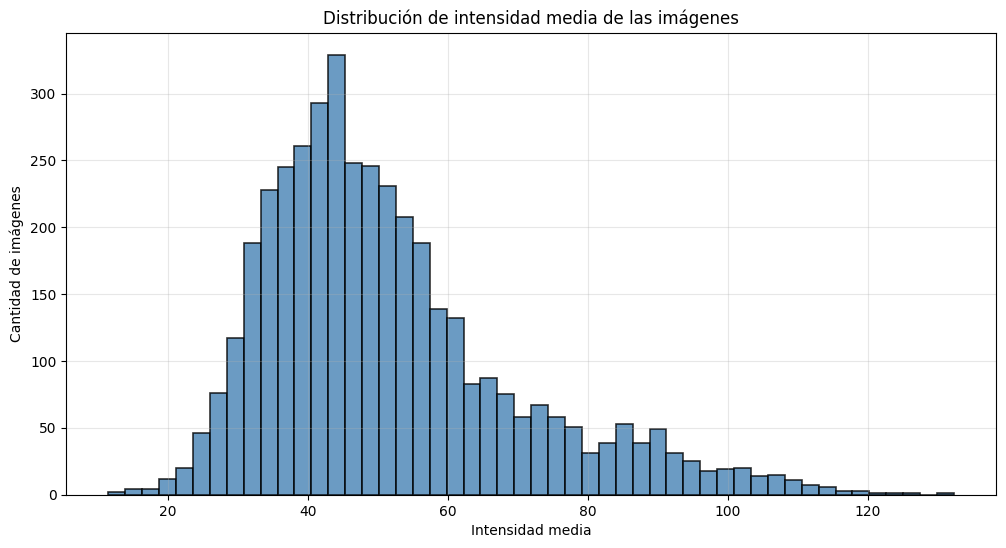

In [44]:
plt.figure(figsize=(12, 6))

plt.hist(df["intensidad_media"], bins=50, color='steelblue', edgecolor='black', alpha=0.8, linewidth=1.2)
plt.title("Distribución de intensidad media de las imágenes")
plt.xlabel("Intensidad media")
plt.ylabel("Cantidad de imágenes")
plt.grid(True, alpha=0.3)
plt.show()

Podemos observar mediante el histograma si existen imágenes con valores extremos de intensidad media, lo cual puede sugerir imágenes sobreexpuestas, muy oscuras o con problemas visuales.

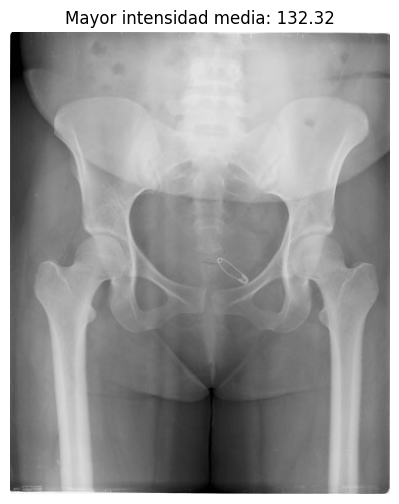

In [45]:
# Visualizamos una imagen con alta intensidad media para verificar su apariencia
if len(df) > 0:
    fila_alta = df.sort_values("intensidad_media", ascending=False).iloc[0]
    img = Image.open(PROJECT_ROOT / fila_alta["ruta"])

    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.title(f"Mayor intensidad media: {fila_alta['intensidad_media']:.2f}")
    plt.axis("off")
    plt.show()

    fila_alta

In [46]:
# En base a la visualización anterior, se filtran solo imágenes extremadamente claras.
# El umbral puede ajustarse si al revisar las muestras se detecta otro comportamiento.
df = df[df["intensidad_media"] < 245]

df.shape

(4083, 14)

In [47]:
categorias = df["categoria"].unique().tolist()
categorias

['fractura', 'no_fractura']

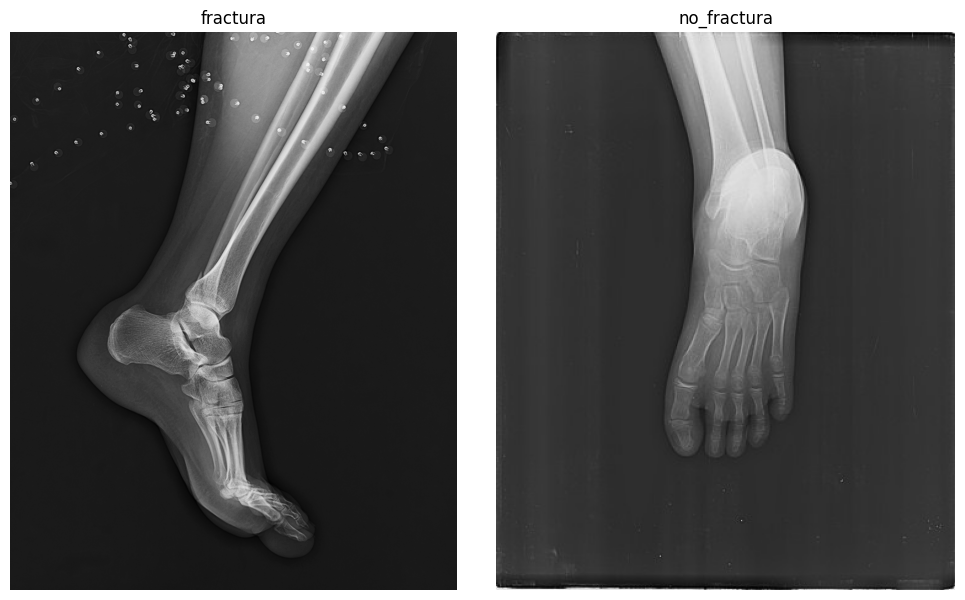

In [48]:
n_cols = 2
n_rows = len(categorias) // n_cols + (len(categorias) % n_cols > 0)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(10, 6*n_rows))
ax = ax.flatten()

for i, categoria in enumerate(categorias):
    ruta_imagen_categoria = PROJECT_ROOT / df[df["categoria"] == categoria].sample(1, random_state=50).iloc[0]["ruta"]
    img = Image.open(ruta_imagen_categoria)

    ax[i].imshow(img, cmap="gray")
    ax[i].set_title(categoria)
    ax[i].axis("off")

for j in range(len(categorias), len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.show()

**Punto 1: Tamaño de las imágenes**

In [49]:
# Resumen estadístico
df[["ancho", "alto", "pixeles_totales", "relacion_aspecto"]].describe().round(2)

,ancho,alto,pixeles_totales,relacion_aspecto
count,4083.00,4083.00,4083.00,4083.00
mean,559.17,634.37,707541.66,0.92
std,539.39,665.29,1768702.88,0.17
min,181.00,214.00,79822.00,0.40
25%,373.00,373.00,169342.00,0.82
50%,373.00,454.00,169342.00,0.82
75%,454.00,454.00,169342.00,1.22
max,2880.00,2880.00,6635520.00,1.74


In [50]:
# Tamaños más frecuentes
tamanios = df.groupby(["ancho", "alto"]).size().reset_index(name="cantidad")
tamanios.sort_values("cantidad", ascending=False).head(10)

,ancho,alto,cantidad
3,373,454,2704
5,454,373,1023
9,2304,2880,303
8,1760,2140,24
10,2880,2304,23
0,181,454,1
1,296,454,1
2,373,214,1
4,454,310,1
6,454,454,1


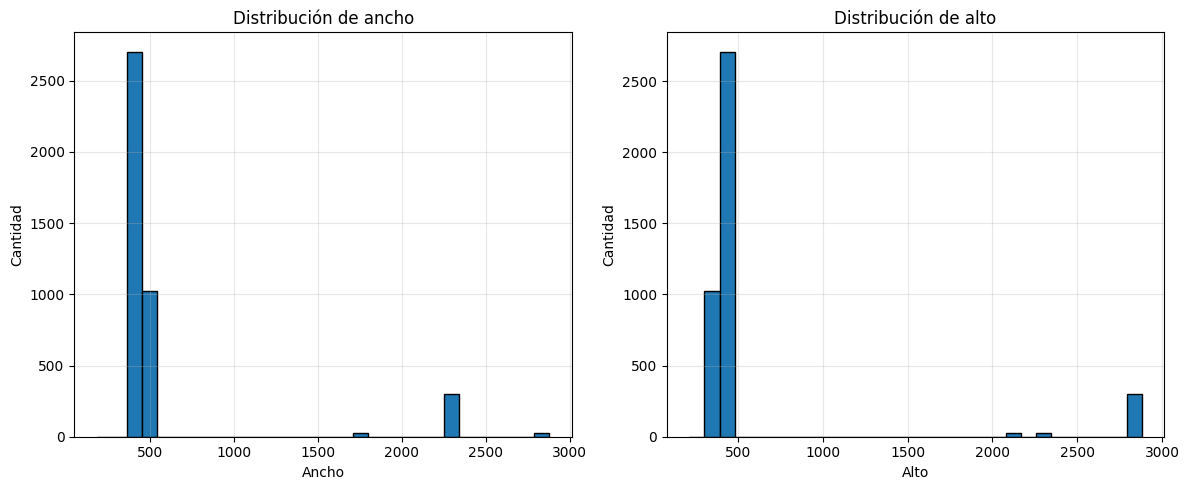

In [51]:
# Gráfico de distribución de ancho y alto
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df["ancho"], bins=30, edgecolor="black")
plt.title("Distribución de ancho")
plt.xlabel("Ancho")
plt.ylabel("Cantidad")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df["alto"], bins=30, edgecolor="black")
plt.title("Distribución de alto")
plt.xlabel("Alto")
plt.ylabel("Cantidad")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

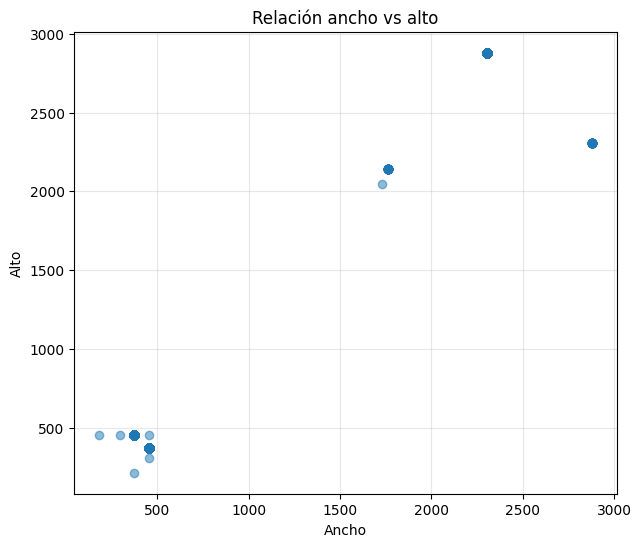

In [52]:
# Relación ancho vs alto
plt.figure(figsize=(7, 6))
plt.scatter(df["ancho"], df["alto"], alpha=0.5)
plt.title("Relación ancho vs alto")
plt.xlabel("Ancho")
plt.ylabel("Alto")
plt.grid(True, alpha=0.3)
plt.show()

### Filtrar imágenes por tamaño mínimo

Eliminar imágenes que tengan un ancho menor a 200 píxeles o un alto menor a 200 píxeles.

In [53]:
# Eliminar imágenes con ancho < 200 o alto < 200
df = df[(df["ancho"] >= 200) & (df["alto"] >= 200)]

print(f"Dataset después de filtrar por tamaño mínimo: {df.shape[0]} imágenes")

Dataset después de filtrar por tamaño mínimo: 4082 imágenes


**Fundamentación:** Las imágenes con baja resolución pueden afectar el entrenamiento porque al reescalarlas se pierde detalle visual relevante. En radiografías, este detalle es importante para diferenciar fracturas de estructuras normales.

### **Distribución de categorías de las imágenes**

In [54]:
# Conteo por categoría
conteo_categorias = df["categoria"].value_counts().sort_values(ascending=False)
conteo_categorias

categoria
no_fractura    3366
fractura        716
Name: count, dtype: int64

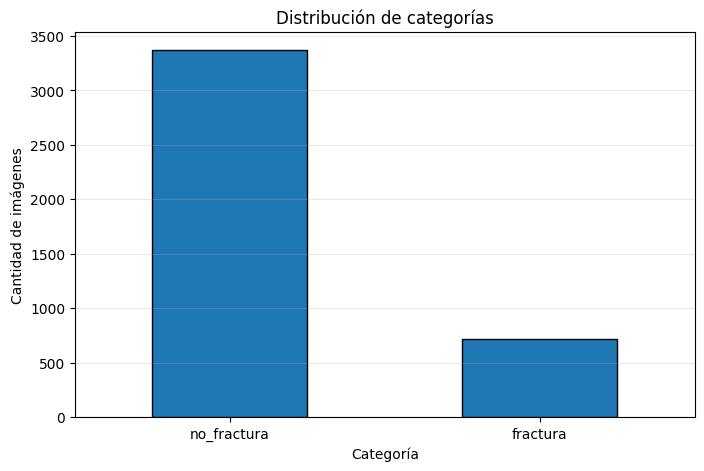

In [55]:
# Gráfico de barras por categoría
plt.figure(figsize=(8, 5))
conteo_categorias.plot(kind="bar", edgecolor="black")
plt.title("Distribución de categorías")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [56]:
# Conteo por categoría y split
tabla_categoria_split = pd.crosstab(df["categoria"], df["split"])
tabla_categoria_split

split,Test,Train
categoria,,
fractura,142,574
no_fractura,673,2693


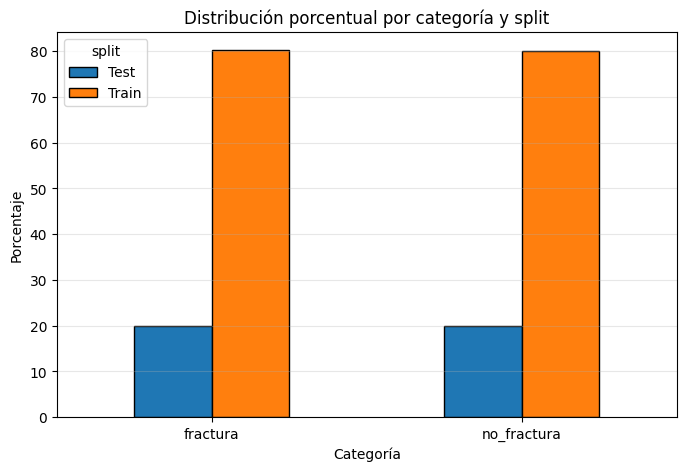

In [57]:
tabla_porcentaje = tabla_categoria_split.div(tabla_categoria_split.sum(axis=1), axis=0) * 100

tabla_porcentaje.plot(kind="bar", figsize=(8, 5), edgecolor="black")
plt.title("Distribución porcentual por categoría y split")
plt.xlabel("Categoría")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

### **Histogramas promedio**

En esta sección visualizaremos los histogramas promedios para posteriormente poder dar un diagnóstico de las imágenes.

In [58]:
# Funciones utiles para análisis de imágenes

def cargar_gris(ruta):
    img = Image.open(ruta).convert("L")
    return np.array(img)

def calcular_histograma_gray(ruta):
    img_gray = cargar_gris(ruta)

    hist, bins = np.histogram(
        img_gray.ravel(),
        bins=256,
        range=(0, 256),
        density=True
    )

    return hist

In [59]:
# Histograma promedio general del dataset
histogramas = []

for ruta_relativa in df["ruta"]:
    ruta_absoluta = PROJECT_ROOT / ruta_relativa
    hist = calcular_histograma_gray(ruta_absoluta)
    histogramas.append(hist)

hist_promedio_general = np.array(histogramas).mean(axis=0)

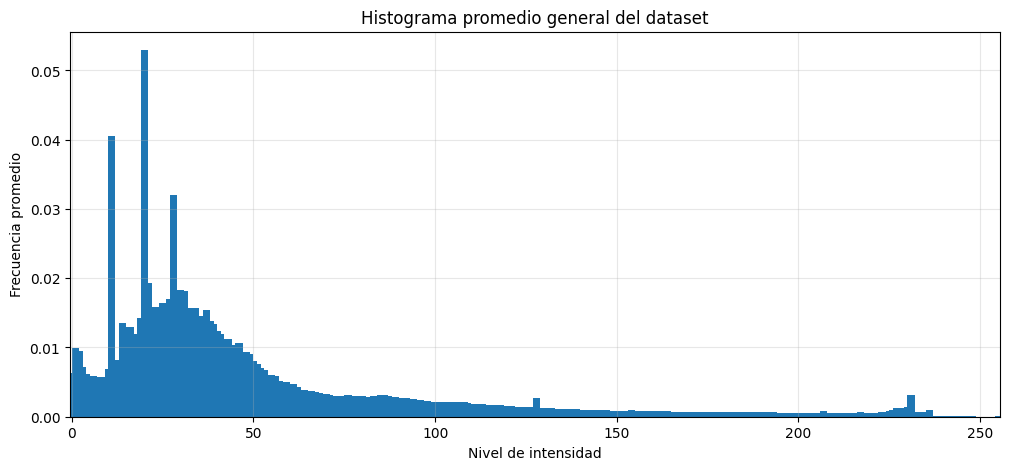

In [60]:
niveles_intensidad = np.arange(256)

plt.figure(figsize=(12, 5))
plt.bar(niveles_intensidad, hist_promedio_general, width=2.)
plt.title("Histograma promedio general del dataset")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Frecuencia promedio")
plt.xlim(-0.5, 255.5)
plt.grid(True, alpha=0.3)
plt.show()

**Conclusión:** Este histograma permite revisar si las radiografías presentan bajo contraste, subexposición o concentración de intensidades en una zona específica. Esto justifica el uso de CLAHE y realce de bordes en el pipeline.

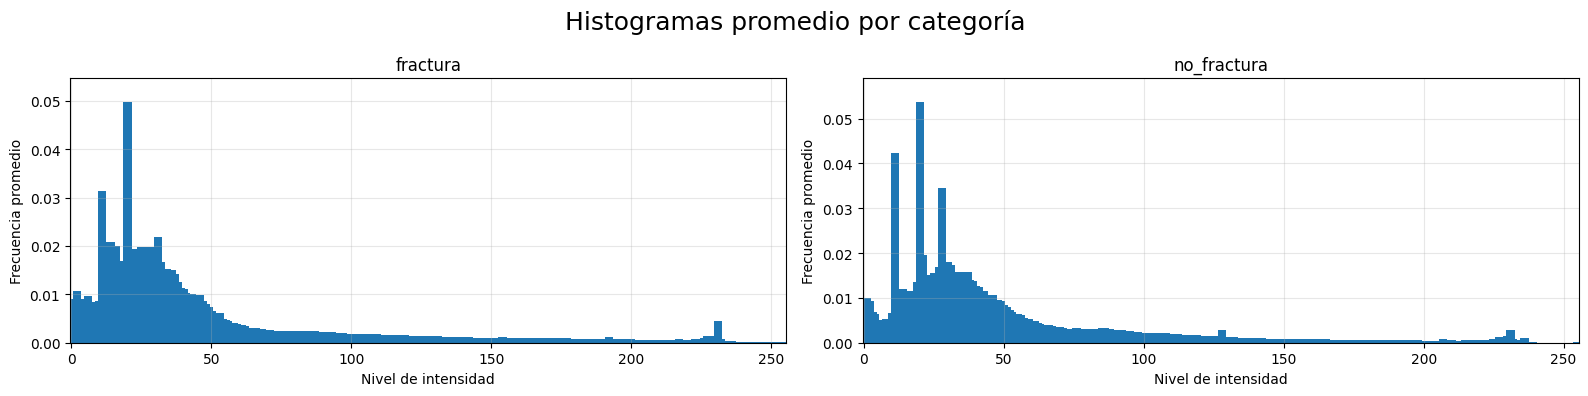

In [61]:
visualizar_histogramas_por_categoria(df)

**Conclusión:** Al comparar los histogramas por categoría podemos observar si las imágenes con fractura y sin fractura presentan diferencias de iluminación o contraste. El objetivo del preprocesamiento es reducir esta variabilidad visual y resaltar estructuras óseas relevantes.

### **Escala de grises de las imágenes**

In [62]:
# Ver cuántas imágenes son RGB y cuántas parecen grises
df["modo"].value_counts()

modo
RGB    3477
L       605
Name: count, dtype: int64

In [63]:
df["es_gris_visual"].value_counts()

es_gris_visual
True    4082
Name: count, dtype: int64

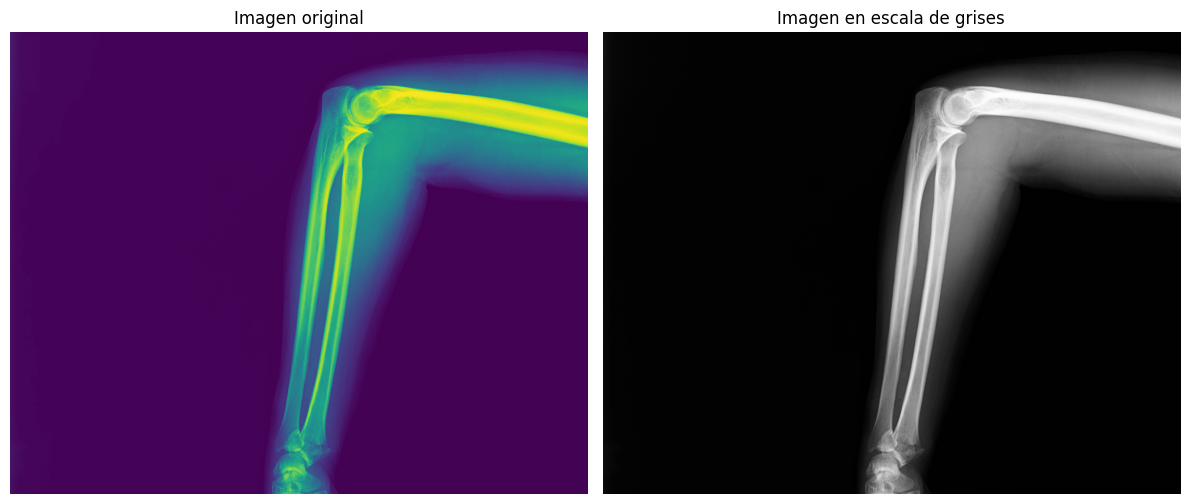

In [64]:
# Mostrar una imagen original y su versión en escala de grises
ruta_ejemplo_relativa = df.iloc[1]["ruta"]
ruta_ejemplo = PROJECT_ROOT / ruta_ejemplo_relativa

img_original = Image.open(ruta_ejemplo)
img_gris = img_original.convert("L")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_original)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_gris, cmap="gray")
plt.title("Imagen en escala de grises")
plt.axis("off")

plt.tight_layout()
plt.show()

## Transformaciones de Imágenes Transformadas

Aplicaremos el pipeline de transformación a **todas las imágenes** y las guardaremos en `data/processed/`, manteniendo la estructura de categorías y splits.

Pipeline:

1. Conversión a escala de grises.
2. Redimensionamiento a 320x320.
3. Filtro de mediana 3x3 para reducir ruido.
4. CLAHE para mejorar contraste local.
5. Unsharp masking para realzar bordes y posibles líneas de fractura.

In [65]:
# Crear las funciones de filtros
def transf_lineal(img, a=1.0, b=0):
    img_float = img.astype(float)
    salida = a * img_float + b
    salida = np.clip(salida, 0, 255)
    return np.rint(salida).astype(np.uint8)


def transf_gamma(img, gamma=1.0, c=1.0):
    img_norm = img.astype(float) / 255.0
    salida = c * (img_norm ** gamma)
    salida = salida * 255
    salida = np.clip(salida, 0, 255)
    return np.rint(salida).astype(np.uint8)


def filtro_media(img, k=3):
    kernel = np.ones((k, k)) / (k * k)
    salida = ndi.convolve(img.astype(float), kernel, mode="reflect")
    return np.clip(salida, 0, 255).astype(np.uint8)


def filtro_mediana(img, k=3):
    salida = ndi.median_filter(img, size=k, mode="reflect")
    return salida.astype(np.uint8)


def unsharp(img, sigma=2, k=1.0):
    img_float = img.astype(float)

    img_blur = ndi.gaussian_filter(img_float, sigma=sigma)
    detalle = img_float - img_blur

    salida = img_float + k * detalle
    salida = np.clip(salida, 0, 255)

    return salida.astype(np.uint8)

In [66]:
def preprocessing_pipeline(ruta_imagen, size=320):
    # Cargar imagen en escala de grises
    img = Image.open(ruta_imagen).convert("L")

    # Redimensionar a 320x320
    img = img.resize((size, size), Image.Resampling.LANCZOS)
    img_arr = np.array(img).astype(np.uint8)

    # Paso 1: Suavizar ruido impulsivo con filtro mediana
    temp = filtro_mediana(img_arr, k=3)

    # Paso 2: Mejorar contraste local con CLAHE
    clahe = exposure.equalize_adapthist(
        temp / 255.0,
        clip_limit=0.03
    )
    clahe = np.clip(clahe * 255, 0, 255).astype(np.uint8)

    # Paso 3: Resaltar bordes con unsharp masking
    resultado = unsharp(clahe, sigma=1.0, k=1)

    return resultado

In [68]:
# Configurar ruta de salida para imágenes procesadas
processed_dir = PROCESSED_PATH / "fractatlas_binario"

print("=" * 70)
print("INICIANDO PREPROCESAMIENTO DE IMÁGENES")
print("=" * 70)

processed_dir.mkdir(parents=True, exist_ok=True)

# Crear estructura de carpetas: processed/split/categoria/
for categoria in df["categoria"].unique():
    for split in df["split"].unique():
        carpeta_destino = processed_dir / split / categoria
        carpeta_destino.mkdir(parents=True, exist_ok=True)
        print(f"✓ Carpeta creada: {carpeta_destino.relative_to(PROJECT_ROOT)}")

print("\n" + "=" * 70)
print("PROCESANDO IMÁGENES...")
print("=" * 70 + "\n")

procesadas = 0
errores = 0
errores_lista = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Procesando imágenes"):
    try:
        ruta_relativa = row["ruta"]
        ruta_original = PROJECT_ROOT / ruta_relativa

        categoria = row["categoria"]
        split = row["split"]
        archivo = row["archivo"]

        carpeta_destino = processed_dir / split / categoria
        ruta_destino = carpeta_destino / archivo

        img_procesada = preprocessing_pipeline(ruta_original)

        img_pil = Image.fromarray(img_procesada)
        img_pil.save(ruta_destino, quality=95)

        procesadas += 1

    except Exception as e:
        errores += 1
        errores_lista.append((ruta_relativa, str(e)))
        print(f"✗ Error procesando {ruta_relativa}: {str(e)}")

print("\n" + "=" * 70)
print("RESUMEN DEL PREPROCESAMIENTO")
print("=" * 70)
print(f"✓ Imágenes procesadas exitosamente: {procesadas}")
print(f"✗ Errores: {errores}")
print(f"Ruta de salida: {processed_dir.relative_to(PROJECT_ROOT)}/")
print("=" * 70)

if errores > 0:
    print("\nDetalles de errores:")
    for ruta, error in errores_lista[:5]:
        print(f"  - {ruta}: {error}")

INICIANDO PREPROCESAMIENTO DE IMÁGENES
✓ Carpeta creada: data\processed\fractatlas_binario\Train\fractura
✓ Carpeta creada: data\processed\fractatlas_binario\Test\fractura
✓ Carpeta creada: data\processed\fractatlas_binario\Train\no_fractura
✓ Carpeta creada: data\processed\fractatlas_binario\Test\no_fractura

PROCESANDO IMÁGENES...



Procesando imágenes:   0%|          | 0/4082 [00:00<?, ?it/s]

Procesando imágenes: 100%|██████████| 4082/4082 [01:37<00:00, 41.75it/s]


RESUMEN DEL PREPROCESAMIENTO
✓ Imágenes procesadas exitosamente: 4082
✗ Errores: 0
Ruta de salida: data\processed\fractatlas_binario/


In [69]:
# Verificar estructura de carpetas creadas
print("\n" + "=" * 70)
print("ESTRUCTURA DE DATASET PROCESADO")
print("=" * 70)
mostrar_estructura(processed_dir, nivel_max=3)


ESTRUCTURA DE DATASET PROCESADO
fractatlas_binario/  (0 imágenes)
    Test/  (0 imágenes)
        fractura/  (142 imágenes)
        no_fractura/  (673 imágenes)
    Train/  (0 imágenes)
        fractura/  (574 imágenes)
        no_fractura/  (2693 imágenes)


In [70]:
# Generamos un nuevo DataFrame con las rutas de las imágenes procesadas para futuras referencias
datos_procesados = []

for split in df["split"].unique():
    for categoria in df["categoria"].unique():
        carpeta = processed_dir / split / categoria
        if carpeta.exists():
            for img_file in carpeta.glob("*.*"):
                img_pros = Image.open(img_file)
                gray_array_pros = np.array(img_pros)

                datos_procesados.append({
                    "ruta": str(img_file.relative_to(PROJECT_ROOT)),
                    "categoria": categoria,
                    "split": split,
                    "intensidad_min": gray_array_pros.min(),
                    "intensidad_max": gray_array_pros.max(),
                    "intensidad_media": gray_array_pros.mean(),
                    "intensidad_std": gray_array_pros.std()
                })

df_procesados = pd.DataFrame(datos_procesados)
df_procesados.head()

,ruta,categoria,split,intensidad_min,intensidad_max,intensidad_media,intensidad_std
0,data\processed\fractatlas_binario\Train\fractu...,fractura,Train,0,255,77.862285,65.889275
1,data\processed\fractatlas_binario\Train\fractu...,fractura,Train,0,255,37.033779,58.179011
2,data\processed\fractatlas_binario\Train\fractu...,fractura,Train,0,255,82.445410,64.182758
3,data\processed\fractatlas_binario\Train\fractu...,fractura,Train,0,255,77.585127,79.626946
4,data\processed\fractatlas_binario\Train\fractu...,fractura,Train,0,255,97.833711,65.213056


In [71]:
# Histograma promedio general del dataset procesado
histogramas_pros = []

for ruta_relativa in df_procesados["ruta"]:
    ruta_absoluta = PROJECT_ROOT / ruta_relativa
    hist = calcular_histograma_gray(ruta_absoluta)
    histogramas_pros.append(hist)

hist_promedio_general_pros = np.array(histogramas_pros).mean(axis=0)

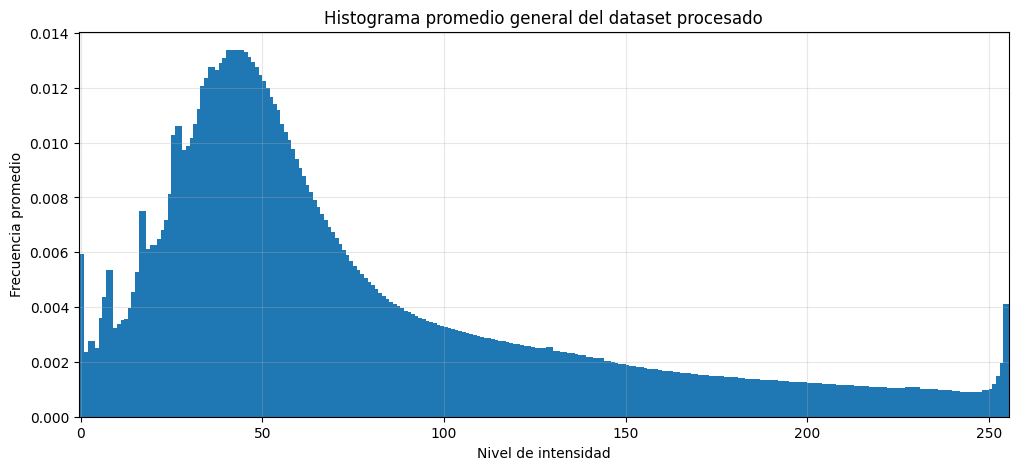

In [72]:
niveles_intensidad = np.arange(256)

plt.figure(figsize=(12, 5))
plt.bar(niveles_intensidad, hist_promedio_general_pros, width=2.)
plt.title("Histograma promedio general del dataset procesado")
plt.xlabel("Nivel de intensidad")
plt.ylabel("Frecuencia promedio")
plt.xlim(-0.5, 255.5)
plt.grid(True, alpha=0.3)
plt.show()

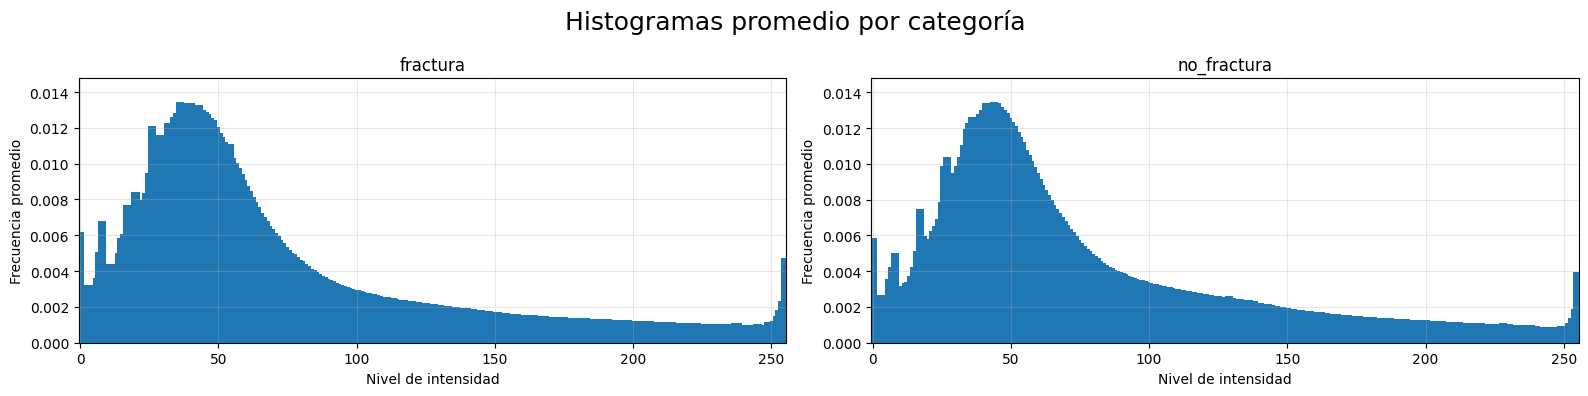

In [73]:
visualizar_histogramas_por_categoria(df_procesados)

**Conclusiones:** En comparación con los histogramas de la data cruda, los histogramas procesados permiten evaluar si el pipeline logró una distribución de intensidades más útil para la CNN. La idea es mejorar contraste local y resaltar estructuras óseas sin cambiar la clase de la imagen.

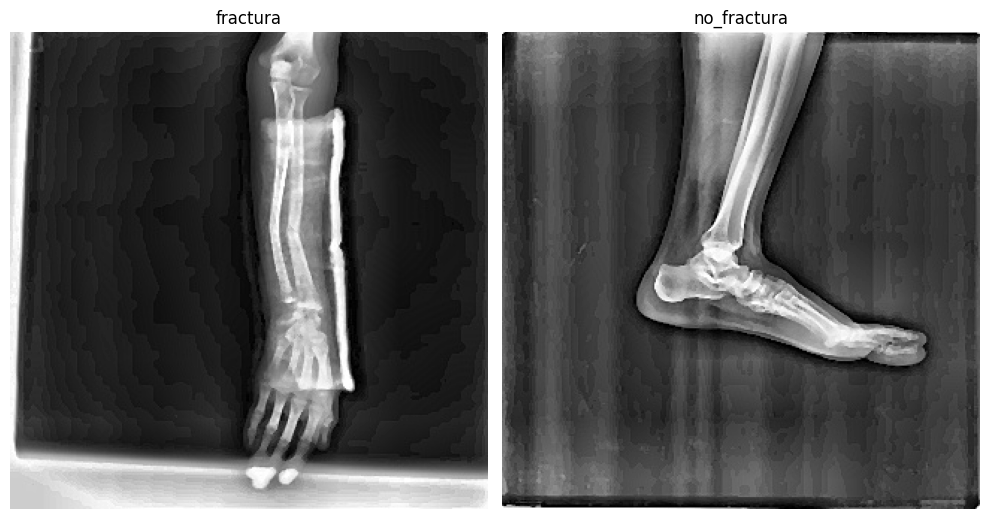

In [76]:
categorias_procesadas = df_procesados["categoria"].unique().tolist()

n_cols = 2
n_rows = len(categorias_procesadas) // n_cols + (len(categorias_procesadas) % n_cols > 0)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(10, 6*n_rows))
ax = ax.flatten()

for i, categoria in enumerate(categorias_procesadas):
    ruta_imagen_categoria = PROJECT_ROOT / df_procesados[df_procesados["categoria"] == categoria].sample(1, random_state=50).iloc[0]["ruta"]

    img = Image.open(ruta_imagen_categoria)

    ax[i].imshow(img, cmap="gray")
    ax[i].set_title(categoria)
    ax[i].axis("off")

for j in range(len(categorias_procesadas), len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.show()

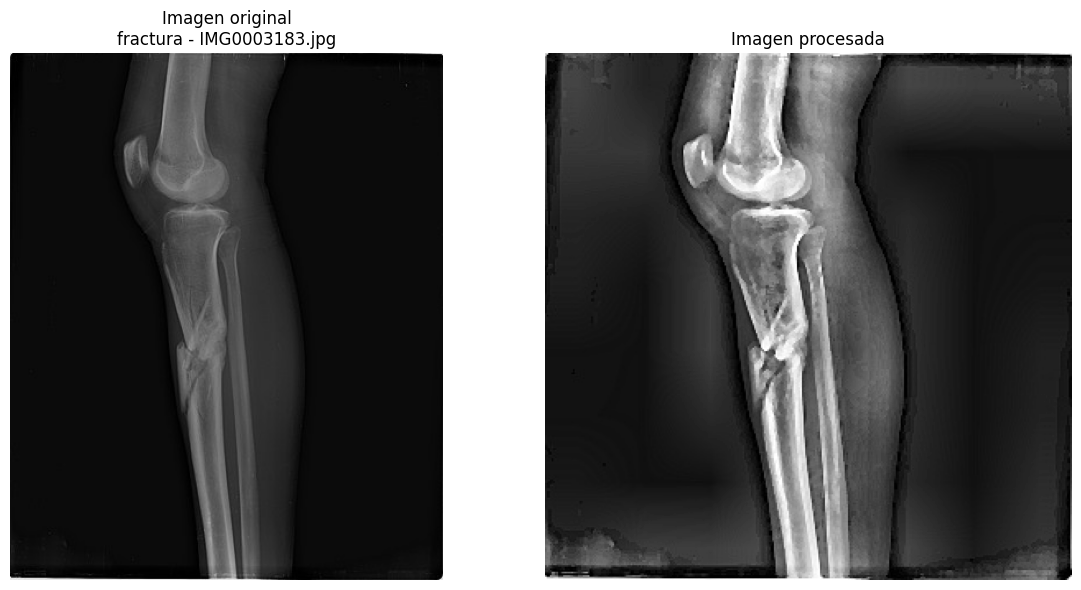

In [ ]:
from pathlib import Path

idx = 550

row_original = df.reset_index(drop=True).iloc[idx]

nombre_archivo = Path(row_original["ruta"]).name
split = row_original["split"]
categoria = row_original["categoria"]

df_proc_reset = df_procesados.reset_index(drop=True)

mask = (
    df_proc_reset["ruta"].apply(lambda x: Path(x).name) == nombre_archivo
) & (
    df_proc_reset["split"] == split
) & (
    df_proc_reset["categoria"] == categoria
)

row_procesada = df_proc_reset[mask].iloc[0]

# Abrimos ambas imágenes
img_original = Image.open(PROJECT_ROOT / row_original["ruta"])
img_procesada = Image.open(PROJECT_ROOT / row_procesada["ruta"])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_original, cmap="gray")
plt.title(f"Imagen original\n{categoria} - {nombre_archivo}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_procesada, cmap="gray")
plt.title("Imagen procesada")
plt.axis("off")

plt.tight_layout()
plt.show()